In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

In [121]:
# Load by file name
R2502_2503 = pd.read_pickle("R2502_2503.pkl")
R2503_2502 = pd.read_pickle("R2503_2502.pkl")

F2504 = pd.read_pickle("2504.pkl")

In [122]:
from pathlib import Path

# 1) Does a directory exist?
base = Path("/home/seismic/AxialFetch/MJ03F-B")
print(base, "→", base.exists(), "(dir)" if base.is_dir() else "(not a dir)")

# 2) Does one specific file exist?
f = base / "MJ03F-B2022DIFF-PRESS-15min.txt"
print(f, "→", f.exists())

# 3) Quick sweep over a pattern
for p in base.glob("MJ03F-B*DIFF-PRESS-15min.txt"):
    print("found:", p.name)


/home/seismic/AxialFetch/MJ03F-B → True (dir)
/home/seismic/AxialFetch/MJ03F-B/MJ03F-B2022DIFF-PRESS-15min.txt → True
found: MJ03F-B2023DIFF-PRESS-15min.txt
found: MJ03F-B2022DIFF-PRESS-15min.txt
found: MJ03F-B2021DIFF-PRESS-15min.txt
found: MJ03F-B2020DIFF-PRESS-15min.txt
found: MJ03F-B2019DIFF-PRESS-15min.txt
found: MJ03F-B2018DIFF-PRESS-15min.txt
found: MJ03F-B2017DIFF-PRESS-15min.txt
found: MJ03F-B2024DIFF-PRESS-15min.txt


In [123]:
import glob
# Specify the path and pattern to load multiple files
file_paths = glob.glob("/data/wsd02/maleen_data/*.Data")  # adjust path as needed

# Read and concatenate all files
df_list = []
for path in file_paths:
    temp_df = pd.read_csv(path, header=None, names=["time", "rawpsi", "depth", "temp"])
    temp_df['time'] = pd.to_datetime(temp_df['time'])
    df_list.append(temp_df)

# Combine into one DataFrame
cp = pd.concat(df_list, ignore_index=True).sort_values('time')

cp['time'] = pd.to_datetime(cp['time'])
cp['central_p']= (cp['depth']*10.05525)

In [125]:
cp['central_p']

0          15184.779931
1          15184.793003
2          15184.784959
3          15184.745743
4          15184.755799
               ...     
5677931    15182.180649
5677932    15182.207798
5677933    15182.203776
5677934    15182.186682
5677935    15182.151489
Name: central_p, Length: 5677936, dtype: float64

Rows in df_pressure: 2552


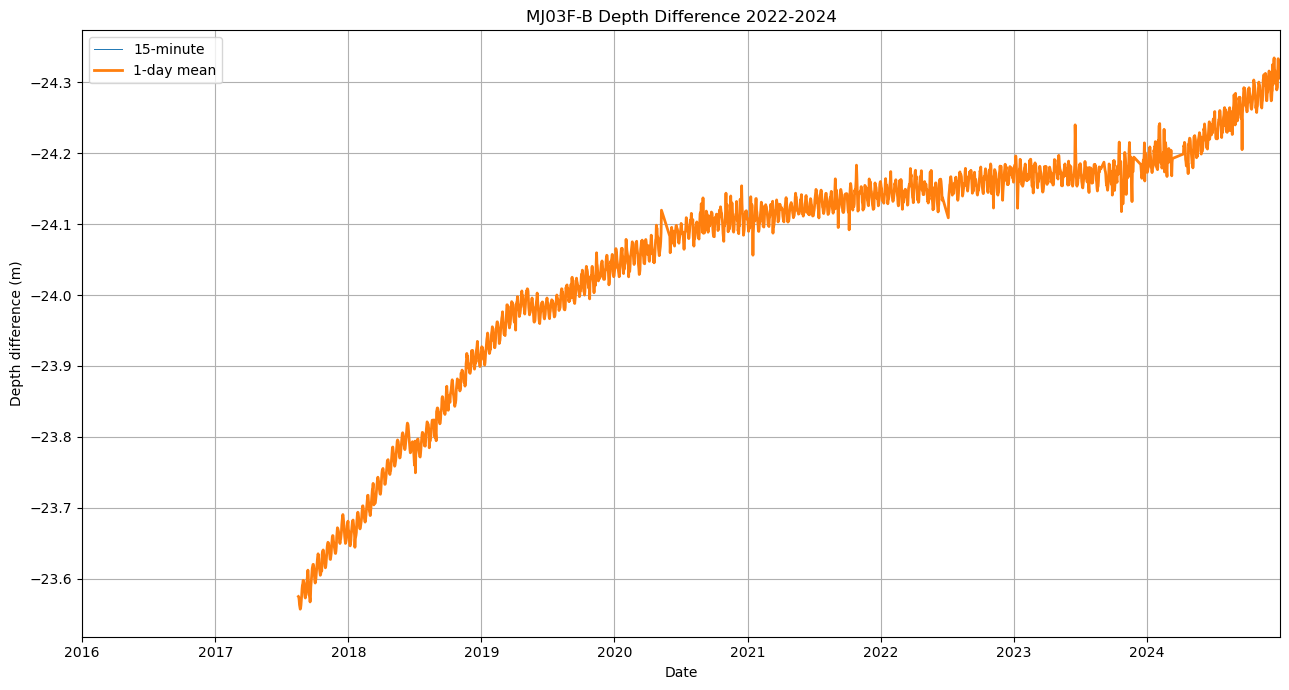

In [179]:
# MJ03F-B depth / pressure processing
# ----------------------------------
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

base_path = Path("/home/seismic/AxialFetch/MJ03F-B")
years     = range(2022, 2025)      # 2022-2024
factor    = 0.67                   # pressure-to-depth conversion

def load_series(years, suffix):
    """Read MJ03F-B DIFF-PRESS files (comma OR whitespace delimited)."""
    frames = []

    for yr in years:
        f = base_path / f"MJ03F-B{yr}DIFF-PRESS-{suffix}.txt"
        if not f.exists():
            continue

        # ---- peek at first line to decide the delimiter -----------------
        with open(f, "r") as fh:
            first_line = fh.readline()

        comma = "," in first_line
        read_opts = dict(
            comment="#",
            engine="python",          # tolerant, handles weird rows
            on_bad_lines="skip"       # silently drop malformed lines
        )

        if comma:
            df = pd.read_csv(f, **read_opts)
            # pick the known columns
            date_col      = df.columns[0]                       # e.g. 'date_1day'
            pressure_col  = (
                "pressure_diff_mean"
                if "pressure_diff_mean" in df.columns
                else df.columns[-1]                             # last numeric col
            )
            df = df[[date_col, pressure_col]]
            df.columns = ["time", "pressure_diff"]
        else:
            # whitespace version: two numeric cols after the date
            df = pd.read_csv(
                f,
                delim_whitespace=True,
                header=None,
                names=["time", "pressure_diff"],
                **read_opts,
            )

        # ---- type conversions & cleanup -------------------------------
        df["time"] = pd.to_datetime(df["time"], format="%Y/%m/%d",
                                    errors="coerce", utc=True)
        df["pressure_diff"] = pd.to_numeric(df["pressure_diff"],
                                            errors="coerce")
        df.dropna(subset=["time", "pressure_diff"], inplace=True)
        frames.append(df)

    if not frames:
        raise FileNotFoundError(f"No DIFF-PRESS-{suffix} data found.")
    return pd.concat(frames, ignore_index=True).sort_values("time")

# ----------------------------------------------------------------------
df_15min = load_series(years, "15min")
df_1day  = load_series(years, "1daymeans")

df_15min["depth_m"] = df_15min["pressure_diff"] * factor
df_1day ["depth_m"] = df_1day ["pressure_diff"] * factor

# minimalist (time, pressure) DF
df_pressure = df_1day[["time", "pressure_diff"]]

print("Rows in df_pressure:", len(df_pressure))   # sanity check

# ----------------------------------------------------------------------
# quick plot
plt.figure(figsize=(13, 7))
plt.plot(df_15min["time"], df_15min["depth_m"],
         label="15-minute", linewidth=0.7)
plt.plot(df_1day["time"],  df_1day["depth_m"],
         label="1-day mean", linewidth=2)
plt.gca().invert_yaxis()
plt.xlabel("Date")
plt.ylabel("Depth difference (m)")
plt.title("MJ03F-B Depth Difference 2022-2024")
plt.xlim(pd.Timestamp(2022, 9, 1, tz="UTC"),
         pd.Timestamp(2024, 10, 1, tz="UTC"))
#plt.ylim(-14.55, -14.45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

del df_1day

Rows in df_pressure: 2552


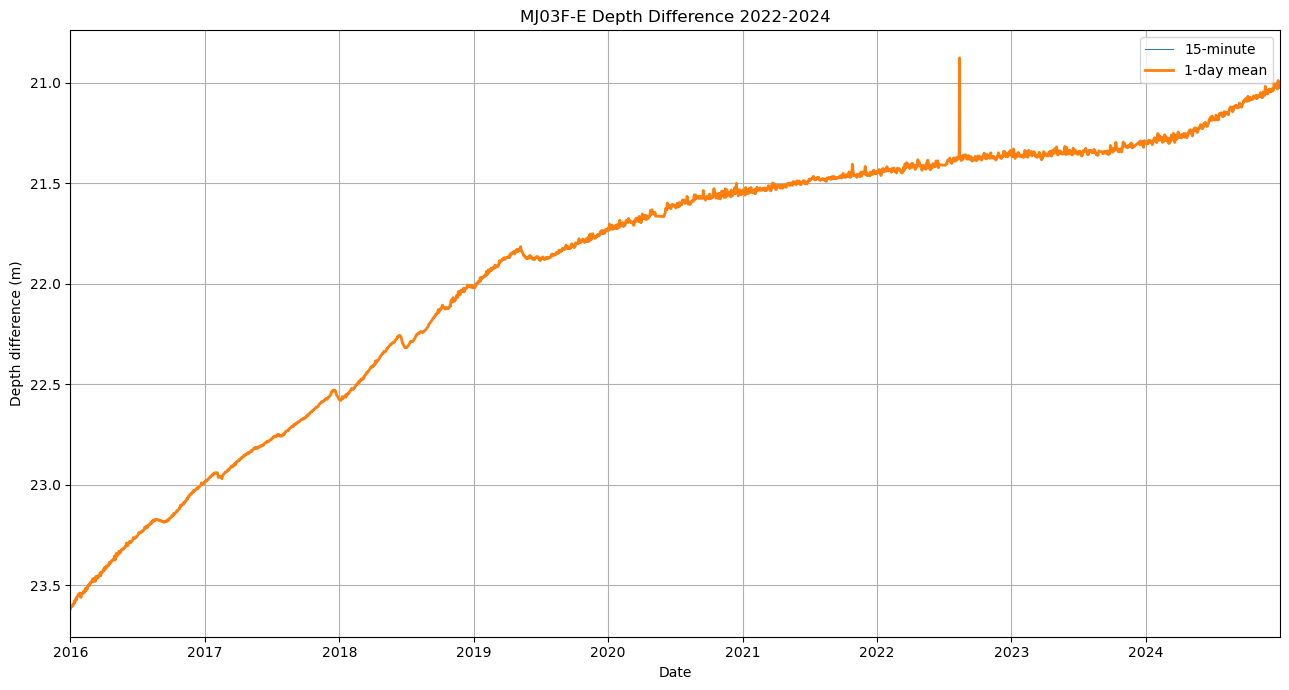

In [178]:
# MJ03F-B depth / pressure processing
# ----------------------------------
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

base_path = Path("/home/seismic/AxialFetch/MJ03F-E")
years     = range(2022, 2025)      # 2022-2024
factor    = 0.67                   # pressure-to-depth conversion

def load_series(years, suffix):
    """Read MJ03F-E DIFF-PRESS files (comma OR whitespace delimited)."""
    frames = []

    for yr in years:
        f = base_path / f"MJ03F-E{yr}DIFF-PRESS-{suffix}.txt"
        if not f.exists():
            continue

        # ---- peek at first line to decide the delimiter -----------------
        with open(f, "r") as fh:
            first_line = fh.readline()

        comma = "," in first_line
        read_opts = dict(
            comment="#",
            engine="python",          # tolerant, handles weird rows
            on_bad_lines="skip"       # silently drop malformed lines
        )

        if comma:
            df = pd.read_csv(f, **read_opts)
            # pick the known columns
            date_col      = df.columns[0]                       # e.g. 'date_1day'
            pressure_col  = (
                "pressure_diff_mean"
                if "pressure_diff_mean" in df.columns
                else df.columns[-1]                             # last numeric col
            )
            df = df[[date_col, pressure_col]]
            df.columns = ["time", "pressure_diff"]
        else:
            # whitespace version: two numeric cols after the date
            df = pd.read_csv(
                f,
                delim_whitespace=True,
                header=None,
                names=["time", "pressure_diff"],
                **read_opts,
            )

        # ---- type conversions & cleanup -------------------------------
        df["time"] = pd.to_datetime(df["time"], format="%Y/%m/%d",
                                    errors="coerce", utc=True)
        df["pressure_diff"] = pd.to_numeric(df["pressure_diff"],
                                            errors="coerce")
        df.dropna(subset=["time", "pressure_diff"], inplace=True)
        frames.append(df)

    if not frames:
        raise FileNotFoundError(f"No DIFF-PRESS-{suffix} data found.")
    return pd.concat(frames, ignore_index=True).sort_values("time")

# ----------------------------------------------------------------------
df_15min = load_series(years, "15min")
df_1day  = load_series(years, "1daymeans")

df_15min["depth_m"] = df_15min["pressure_diff"] * factor
df_1day ["depth_m"] = df_1day ["pressure_diff"] * factor

# minimalist (time, pressure) DF
df_pressure1 = df_1day[["time", "pressure_diff"]]

print("Rows in df_pressure:", len(df_pressure))   # sanity check

# ----------------------------------------------------------------------
# quick plot
plt.figure(figsize=(13, 7))
plt.plot(df_15min["time"], df_15min["depth_m"],
         label="15-minute", linewidth=0.7)
plt.plot(df_1day["time"],  df_1day["depth_m"],
         label="1-day mean", linewidth=2)
plt.gca().invert_yaxis()
plt.xlabel("Date")
plt.ylabel("Depth difference (m)")
plt.title("MJ03F-E Depth Difference 2022-2024")
plt.xlim(pd.Timestamp(2022, 9, 1, tz="UTC"),
         pd.Timestamp(2024, 10, 1, tz="UTC"))
plt.ylim(8.6, 8.47)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [180]:
import pandas as pd

# ------------------------------------------------------------------
# 1) helper → convert any table to a clean UTC-indexed Series
# ------------------------------------------------------------------
def to_series(df, time_col, value_col, fmt=None):
    s = (
        df[[time_col, value_col]]
        .assign(**{time_col: lambda d: pd.to_datetime(
            d[time_col], format=fmt, utc=True)})
        .set_index(time_col)[value_col]
        .astype(float)
        .sort_index()
        .loc[lambda x: ~x.index.duplicated(keep="first")]
    )
    return s

# ------------------------------------------------------------------
# 2) build the master grid from R2503_2504  (distance d1)
# ------------------------------------------------------------------
d1 = to_series(R2503_2502, "Record Time", "Moving Average")

df_var = d1.to_frame("d1")   # index = time, one column so far

# ------------------------------------------------------------------
# 3) prepare the other source series
# ------------------------------------------------------------------
# pressure difference p1 (comes from df_pressure)
pd1 = (
    df_pressure.assign(time=pd.to_datetime(df_pressure["time"], utc=True))
               .set_index("time")["pressure_diff"]
               .astype(float)
               .sort_index()
               .loc[lambda x: ~x.index.duplicated(keep="first")]
)

pd2 = (
    df_pressure1.assign(time=pd.to_datetime(df_pressure1["time"], utc=True))
               .set_index("time")["pressure_diff"]
               .astype(float)
               .sort_index()
               .loc[lambda x: ~x.index.duplicated(keep="first")]
)

# distance opposite direction d2
d2 = to_series(R2502_2503, "Record Time", "Moving Average")


# -- 2. create cp1 (central pressure) ----------------------------------------
cp1 = (
    cp
        .assign(time=pd.to_datetime(cp["time"], utc=True))
        .set_index("time")["central_p"]
        .astype(float)
        .sort_index()
        .loc[lambda s: ~s.index.duplicated(keep="first")]
)

# -- 3. combine, align on common timestamps, compute p1 = cp1 – dp ----------
pressure_df = (
    pd.concat({"cp1": cp1, "pd1": pd1, "pd2": pd2}, axis=1)   # align on DateTime index
      .dropna(subset=["cp1", "pd1", "pd2"])             # keep rows where BOTH exist
)



In [181]:
pressure_df

,cp1,pd1,pd2
time,,,
2022-01-01 00:00:00+00:00,15184.779931,-14.464230,12.844196
2022-01-02 00:00:00+00:00,15184.646196,-14.462274,12.841610
2022-01-03 00:00:00+00:00,15184.533577,-14.461272,12.838037
2022-01-04 00:00:00+00:00,15184.461180,-14.455118,12.842542
2022-01-05 00:00:00+00:00,15184.777920,-14.450818,12.842349
...,...,...,...
2024-12-27 00:00:00+00:00,15181.645710,-14.562579,12.584945
2024-12-28 00:00:00+00:00,15181.807599,-14.559589,12.590025
2024-12-29 00:00:00+00:00,15182.182660,-14.563757,12.580734


In [173]:
import pandas as pd
import numpy as np

# ------------------------------------------------------------------
# 0)  PREP – copy & add depth column just once
# ------------------------------------------------------------------
df = pressure_df.copy()
df.index = pd.to_datetime(df.index)

rho, g = 1025.0, 9.81                       # seawater density + gravity
df["depth_m"] = df["cp1"] * 1_000 / (rho * g)

# ------------------------------------------------------------------
# 1)  FUNCTION: change over an arbitrary interval
# ------------------------------------------------------------------
def interval_change(df, start, end, days=7):
    """
    Compute 7-day-median change for depth, pd1, pd2
    between *start* and *end* (inclusive).

    Parameters
    ----------
    df : DataFrame with columns cp1 (kPa), pd1, pd2, depth_m
    start, end : str or pandas-compatible timestamps
    days : int, size of median window at each edge

    Returns
    -------
    Series with Δdepth_m, Δpd1_psi, Δpd2_psi, depth_per_pd2
    """
    # slice the DataFrame
    block = df.loc[start:end]
    if block.empty or len(block) < 2 * days:
        raise ValueError("Interval too short or outside data range.")

    first = block.iloc[:days].median()
    last  = block.iloc[-days:].median()
    diff  = last - first

    out = pd.Series({
        "Δdepth_m": diff["depth_m"],
        "Δpd1_psi": diff["pd1"],
        "Δpd2_psi": diff["pd2"],
    })
    out["depth_per_pd2"] = out["Δdepth_m"] / out["Δpd2_psi"]
    return out

# ------------------------------------------------------------------
# 2)  EXAMPLES
# ------------------------------------------------------------------
# Single interval
result = interval_change(df, "2022-09-01", "2024-09-01")
#print(result.round(4))

# Multiple intervals in a loop
intervals = [
    ("2022-09-01", "2024-09-01"),
]
summary = pd.DataFrame(
    [interval_change(df, s, e) for s, e in intervals],
    index=[f"{s} → {e}" for s, e in intervals]
)
print(summary.round(4))


                         Δdepth_m  Δpd1_psi  Δpd2_psi  depth_per_pd2
2022-09-01 → 2024-09-01   -0.1298   -0.0573   -0.1491         0.8708


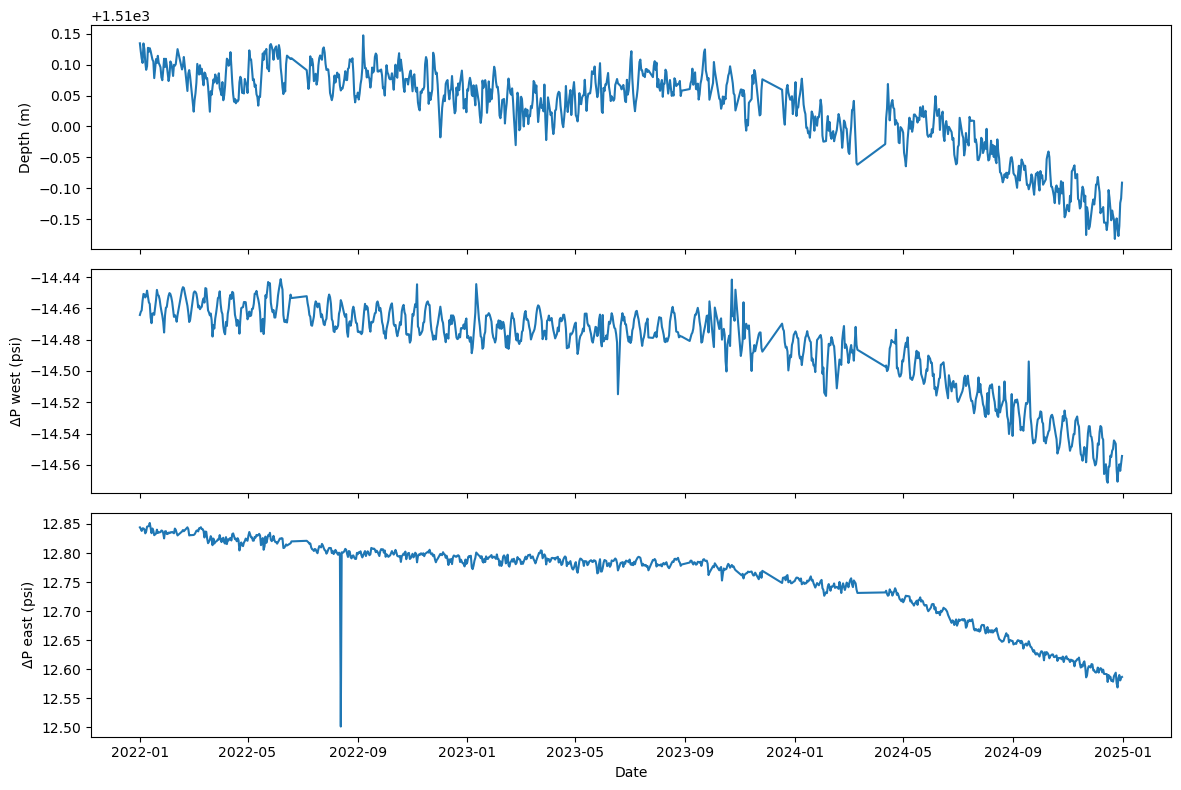

In [165]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- 1.  Make sure we have depth in metres --------------------
df = pressure_df.copy()
df.index = pd.to_datetime(df.index)

rho, g = 1025.0, 9.81
df["depth_m"] = df["cp1"] * 1000 / (rho * g)   # kPa → Pa → depth (m)

# --- 2.  Plot -------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# depth (positive down … invert y-axis if you prefer “depth” downwards)
axes[0].plot(df.index, df["depth_m"])
axes[0].set_ylabel("Depth (m)")
#axes[0].invert_yaxis()          # comment this out if you want depth up

# west differential pressure (pd1, psi)
axes[1].plot(df.index, df["pd1"])
axes[1].set_ylabel("ΔP west (psi)")

# east differential pressure (pd2, psi)
axes[2].plot(df.index, df["pd2"])
axes[2].set_ylabel("ΔP east (psi)")
axes[2].set_xlabel("Date")

plt.tight_layout()
plt.show()


In [182]:
pressure_df["p1"] = pressure_df["cp1"] - (pressure_df["pd1"]*6.89476)
pressure_df["p2"] = pressure_df["cp1"] - (pressure_df["pd2"]*6.89476)
# -- 4. tidy up columns -------------------------------------------------------
pressure_df.index.name = "Datetime"             # give index a name
pressure_df = pressure_df.reset_index()[["Datetime", "p1", "p2","cp1"]]

p1 = to_series(pressure_df, "Datetime", "p1")
p2 = to_series(pressure_df, "Datetime", "p2")
p3 = to_series(pressure_df, "Datetime", "cp1")

In [183]:
# ------------------------------------------------------------------
# 4) interpolate everything onto the master grid
# ------------------------------------------------------------------
def onto_master(source, master_index):
    union = source.reindex(master_index.union(source.index))
    filled = union.interpolate("time")
    return filled.reindex(master_index)

df_var["p1"] = onto_master(p1, df_var.index)
df_var["d2"] = onto_master(d2, df_var.index)
df_var["p2"] = onto_master(p2, df_var.index)
df_var["p3"] = onto_master(p3, df_var.index)

# optional order
df_var = df_var[["p1", "p2", "p3", "d1", "d2"]]

# reset index so 'time' is a normal column
df_var = df_var.reset_index().rename(columns={"index": "time"})


In [184]:
df_var = df_var.dropna().reset_index(drop=True)

import pandas as pd

cutoff = pd.Timestamp(2022, 9, 7, tz="UTC")

# ensure 'time' is datetime and remove earlier rows
df_var["Record Time"] = pd.to_datetime(df_var["Record Time"], utc=True)
df_var = df_var[df_var["Record Time"] >= cutoff].reset_index(drop=True)


In [185]:
df_var

,Record Time,p1,p2,p3,d1,d2
0,2022-09-07 00:30:00+00:00,15284.659082,15096.674391,15184.902438,326022.266908,326024.548452
1,2022-09-07 04:30:00+00:00,15284.593786,15096.612347,15184.844787,326021.826491,326024.289944
2,2022-09-07 08:30:00+00:00,15284.528490,15096.550302,15184.787137,326021.427715,326024.031436
3,2022-09-07 12:30:00+00:00,15284.463195,15096.488258,15184.729487,326021.086461,326024.111645
4,2022-09-07 16:30:00+00:00,15284.397899,15096.426213,15184.671837,326021.196970,326024.937890
...,...,...,...,...,...,...
4341,2024-09-04 04:30:00+00:00,15282.616718,15095.326788,15182.506816,326033.502558,326036.154024
4342,2024-09-04 08:30:00+00:00,15282.598807,15095.305834,15182.491063,326033.381872,326036.201798
4343,2024-09-04 12:30:00+00:00,15282.580896,15095.284880,15182.475310,326033.309222,326036.249573
4344,2024-09-04 16:30:00+00:00,15282.562985,15095.263926,15182.459556,326033.322913,326036.285403


Text(0.5, 1.0, 'East - West Distance')

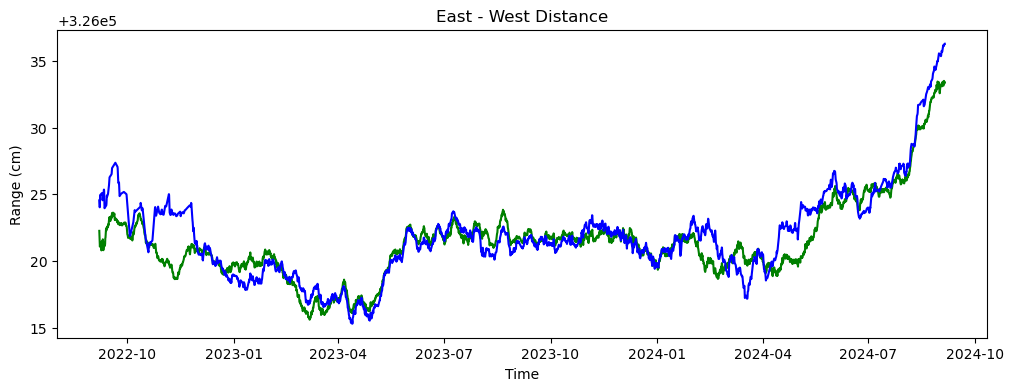

In [186]:
plt.figure(figsize=(12, 4))
plt.plot(df_var['Record Time'],df_var['d1'],"green")
plt.plot(df_var['Record Time'],df_var['d2'],"blue")
plt.xlabel("Time")
plt.ylabel("Range (cm)")
plt.title("East - West Distance")

In [187]:
326022.266908-326033.389644

-11.122735999990255

Text(0, 0.5, 'Pressure (kPa)')

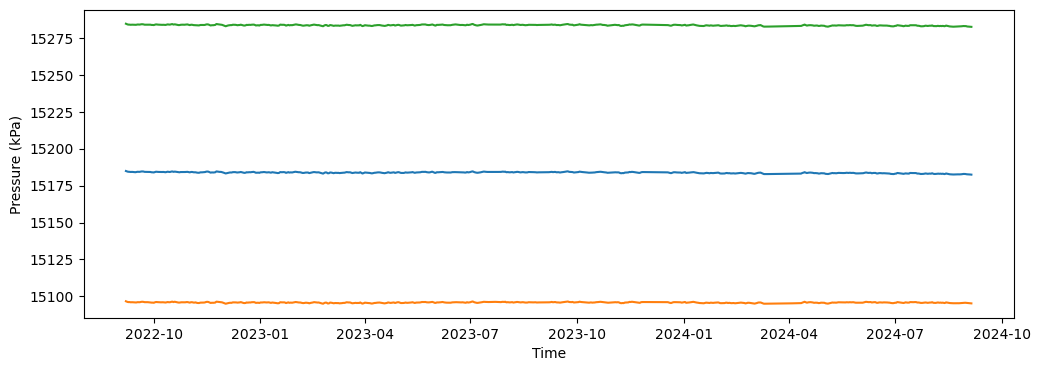

In [198]:
plt.figure(figsize=(12, 4))
plt.plot(time,p3, label = "Central Pressure")
plt.plot(time,p2, label = "West Pressure")
plt.plot(time,p1, label = "East Pressure")
plt.xlabel("Time")
plt.ylabel("Pressure (kPa)")

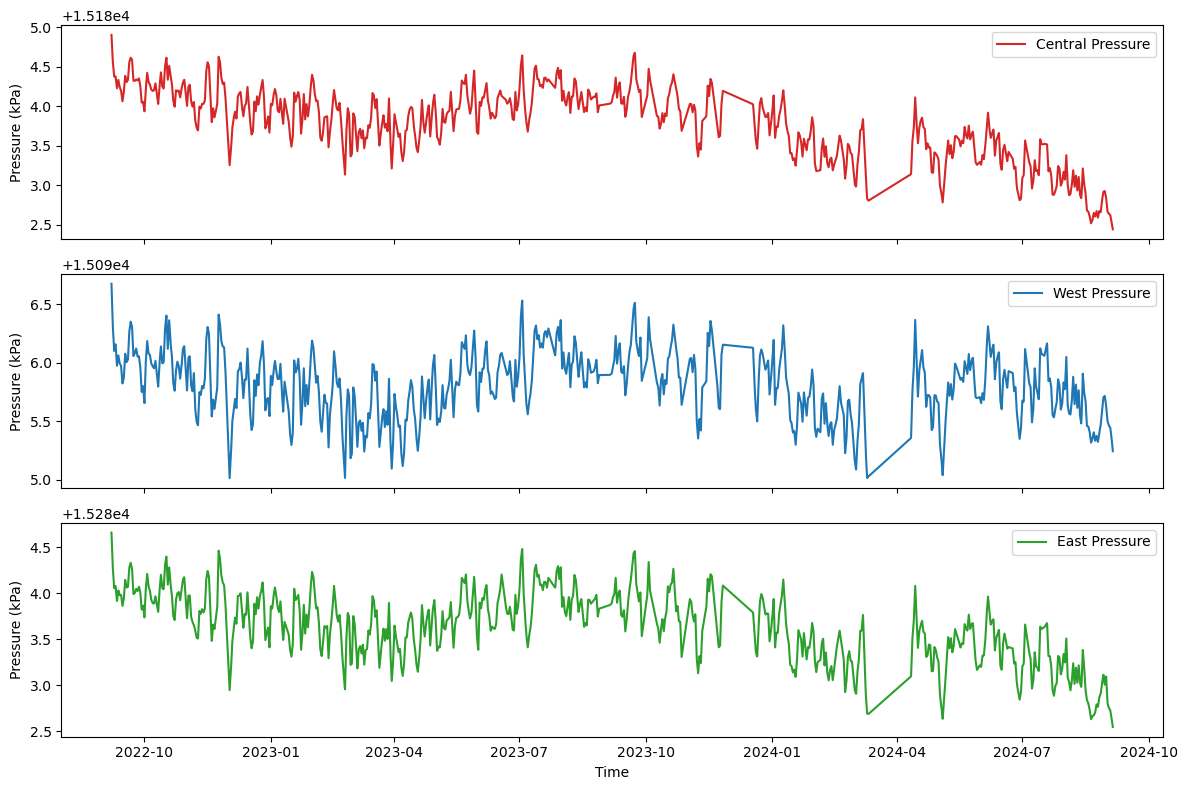

In [199]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Central Pressure
axs[0].plot(time, p3, label="Central Pressure", color='tab:red')
axs[0].set_ylabel("Pressure (kPa)")
axs[0].legend(loc="upper right")

# West Pressure
axs[1].plot(time, p2, label="West Pressure", color='tab:blue')
axs[1].set_ylabel("Pressure (kPa)")
axs[1].legend(loc="upper right")

# East Pressure
axs[2].plot(time, p1, label="East Pressure", color='tab:green')
axs[2].set_xlabel("Time")
axs[2].set_ylabel("Pressure (kPa)")
axs[2].legend(loc="upper right")

plt.tight_layout()
plt.show()


In [189]:
import numpy as np

#-------------------------------------------------
# 1) EXTRACT ARRAYS
#-------------------------------------------------
time  = df_var['Record Time'].values      # datetime64
p1    = df_var['p1'].values               # Pressure E
p2    = df_var['p2'].values               # Pressure W
p3    = df_var['p3'].values               # Pressure C
r_WE  = df_var['d1'].values               # range W → E
r_EW  = df_var['d2'].values               # range E → W

#-------------------------------------------------
# 2) TIME  →  FLOAT DAYS
#-------------------------------------------------
t_days = (time - time[0]) / np.timedelta64(1, 'D')

#-------------------------------------------------
# 3) PERIODIC TERMS
#-------------------------------------------------
T_year = 365.25
ω      = 2.0 * np.pi / T_year
sin_t  = np.sin(ω * t_days)
cos_t  = np.cos(ω * t_days)

#-------------------------------------------------
# 4) STANDARDISE PRESSURES  (z-scored)
#-------------------------------------------------
p1_z = (p1 - p1.mean()) / p1.std()
p2_z = (p2 - p2.mean()) / p2.std()
p3_z = (p3 - p3.mean()) / p3.std()

#-------------------------------------------------
# 5) DESIGN MATRIX  (N × 6)  with intercept
#     R(t) = C + a·p1_z + b·p2_z + c·p3_z + d·sin + e·cos
#-------------------------------------------------
A = np.column_stack([np.ones_like(p1), p1_z, p2_z, p3_z, sin_t, cos_t])

#-------------------------------------------------
# 6) LEAST-SQUARES FITS
#-------------------------------------------------
x_WE, *_ = np.linalg.lstsq(A, r_WE, rcond=None)   # (C, a, b, c, d, e)  for W→E
x_EW, *_ = np.linalg.lstsq(A, r_EW, rcond=None)   # (C, a, b, c, d, e)  for E→W

r_WE_fit = A @ x_WE
r_EW_fit = A @ x_EW

#-------------------------------------------------
# 7) RESULTS
#-------------------------------------------------
print("==== Range W→E coefficients ====")
print(f"C_WE  (intercept) : {x_WE[0]:.6f}")
print(f"a_WE  (Pw)     : {x_WE[1]:.6f}")
print(f"b_WE  (Pe)     : {x_WE[2]:.6f}")
print(f"c_WE  (Pc)     : {x_WE[3]:.6f}")
print(f"d_WE  (annual sin): {x_WE[4]:.6f}")
print(f"e_WE  (annual cos): {x_WE[5]:.6f}")

print("\n==== Range E→W coefficients ====")
print(f"C_EW  (intercept) : {x_EW[0]:.6f}")
print(f"a_EW  (Pw)     : {x_EW[1]:.6f}")
print(f"b_EW  (Pe)     : {x_EW[2]:.6f}")
print(f"c_EW  (Pc)     : {x_EW[3]:.6f}")
print(f"d_EW  (annual sin): {x_EW[4]:.6f}")
print(f"e_EW  (annual cos): {x_EW[5]:.6f}")


==== Range W→E coefficients ====
C_WE  (intercept) : 326021.455348
a_WE  (Pw)     : 0.917761
b_WE  (Pe)     : 1.693006
c_WE  (Pc)     : -3.829171
d_WE  (annual sin): 0.200308
e_WE  (annual cos): 2.528005

==== Range E→W coefficients ====
C_EW  (intercept) : 326021.908112
a_EW  (Pw)     : 1.028387
b_EW  (Pe)     : 1.825209
c_EW  (Pc)     : -4.189993
d_EW  (annual sin): 0.458872
e_EW  (annual cos): 2.804203


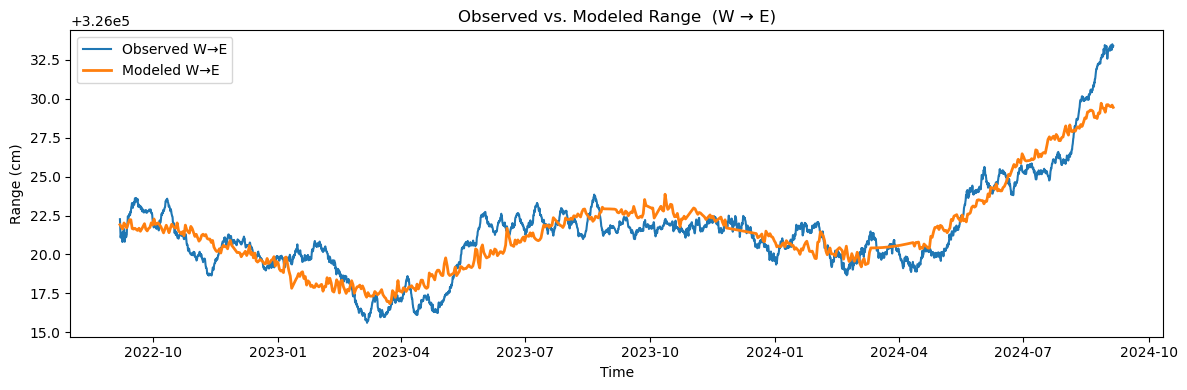

In [190]:
import matplotlib.pyplot as plt

# -------------------------------------------------------------
# OBSERVED vs MODELED — RANGE  W → E   (r_WE)
# -------------------------------------------------------------
plt.figure(figsize=(12, 4))
plt.plot(df_var['Record Time'], r_WE,      label='Observed W→E')
plt.plot(df_var['Record Time'], r_WE_fit,  label='Modeled W→E', linewidth=2)
plt.xlabel("Time")
plt.ylabel("Range (cm)")
plt.title("Observed vs. Modeled Range  (W → E)")
plt.legend()
plt.tight_layout()
plt.show()



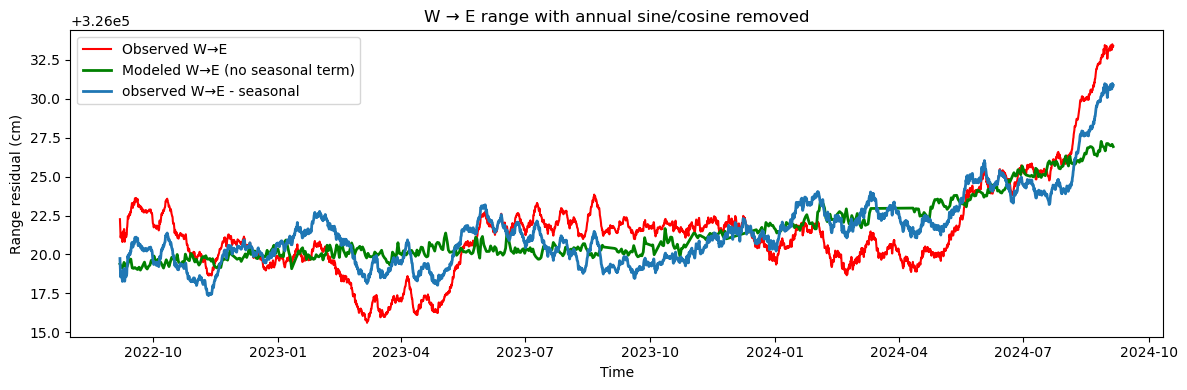

In [191]:
import matplotlib.pyplot as plt
import numpy as np

# --- 8) SEASONAL CONTRIBUTION ---------------------------------------------
season_WE = x_WE[4] * sin_t + x_WE[5] * cos_t          #  d·sin + e·cos

# --- 9) DE-SEASONALISE -----------------------------------------------------
r_WE_deseas_fit  = r_WE_fit  - season_WE               # model     – seasonality
obs_deseas = r_WE  - season_WE                 # (leaves C + pressure terms)

# --- 10) PLOT --------------------------------------------------------------
plt.figure(figsize=(12, 4))
plt.plot(df_var['Record Time'], r_WE,"red", label='Observed W→E ')
plt.plot(df_var['Record Time'], r_WE_deseas_fit,"green", label='Modeled W→E (no seasonal term)', linewidth=2)
plt.plot(df_var['Record Time'], obs_deseas, label='observed W→E - seasonal', linewidth=2)
#plt.axhline(0, color='k', lw=0.75, alpha=0.3)
plt.xlabel("Time")
plt.ylabel("Range residual (cm)")
plt.title("W → E range with annual sine/cosine removed")
plt.legend()
plt.tight_layout()
plt.show()


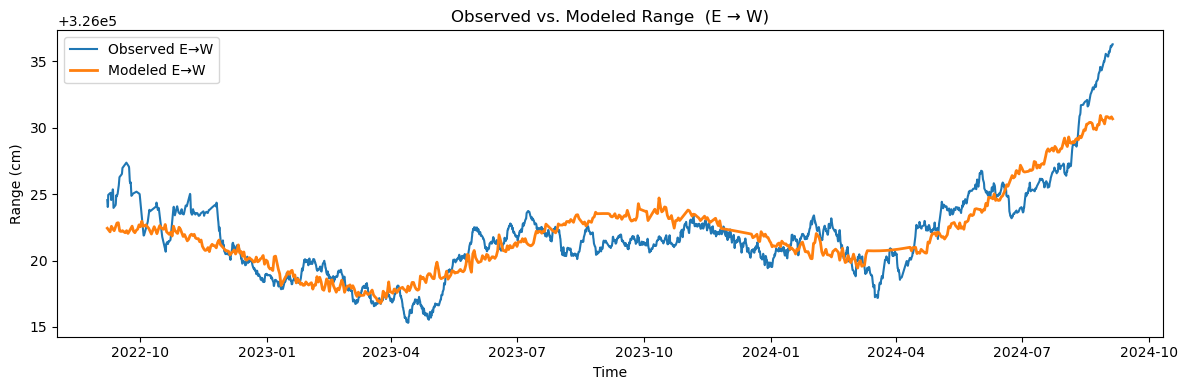

In [192]:

# -------------------------------------------------------------
# OBSERVED vs MODELED — RANGE  E → W   (r_EW)
# -------------------------------------------------------------
plt.figure(figsize=(12, 4))
plt.plot(df_var['Record Time'], r_EW,      label='Observed E→W')
plt.plot(df_var['Record Time'], r_EW_fit,  label='Modeled E→W', linewidth=2)
plt.xlabel("Time")
plt.ylabel("Range (cm)")
plt.title("Observed vs. Modeled Range  (E → W)")
plt.legend()
plt.tight_layout()
plt.show()

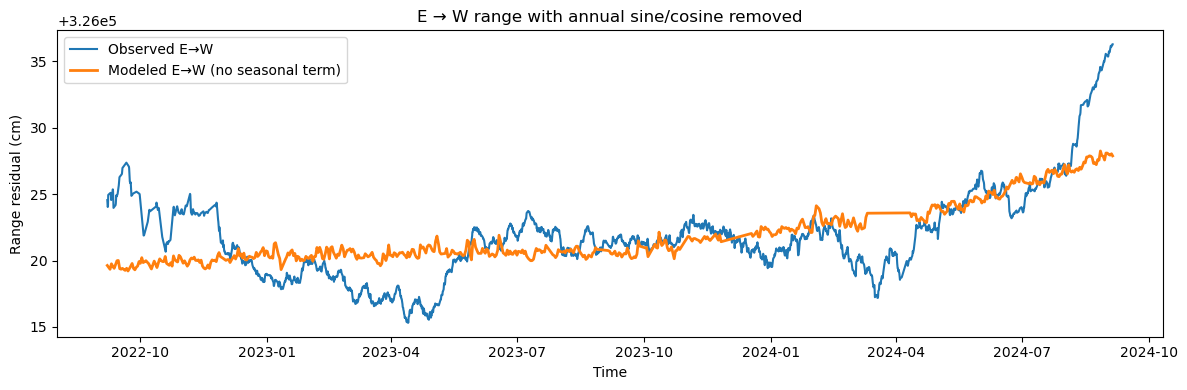

In [193]:
import matplotlib.pyplot as plt
import numpy as np

# --- 8) SEASONAL CONTRIBUTION ---------------------------------------------
season_EW = x_EW[4] * sin_t + x_EW[5] * cos_t          #  d·sin + e·cos

# --- 9) DE-SEASONALISE -----------------------------------------------------
r_EW_deseas_fit  = r_EW_fit  - season_EW              # model     – seasonality
                                                     # (leaves C + pressure terms)

# --- 10) PLOT --------------------------------------------------------------
plt.figure(figsize=(12, 4))
plt.plot(df_var['Record Time'], r_EW, label='Observed E→W ')
plt.plot(df_var['Record Time'], r_EW_deseas_fit, label='Modeled E→W (no seasonal term)', linewidth=2)
#plt.axhline(0, color='k', lw=0.75, alpha=0.3)
plt.xlabel("Time")
plt.ylabel("Range residual (cm)")
plt.title("E → W range with annual sine/cosine removed")
plt.legend()
plt.tight_layout()
plt.show()


In [194]:

print('R² (E→W) =', r2_score(r_EW,  r_EW_fit))
print('R² (W→E) =', r2_score(r_WE,  r_WE_fit))


R² (E→W) = 0.7423808550915849
R² (W→E) = 0.8279395573573254


Text(0, 0.5, 'residual (cm)')

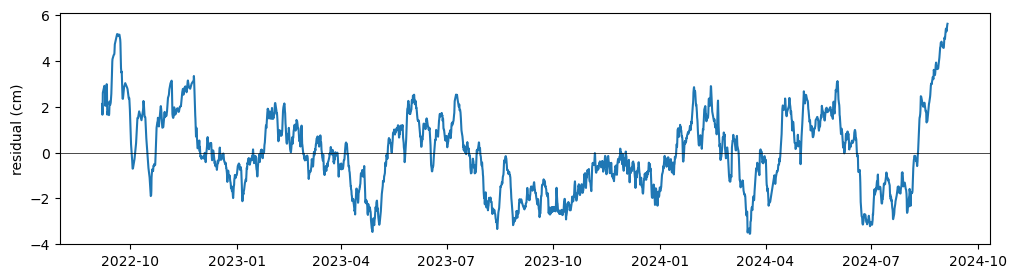

In [195]:
plt.figure(figsize=(12,3))
plt.plot(df_var['Record Time'], r_EW - r_EW_fit)
plt.axhline(0,color='k',lw=0.5); plt.ylabel('residual (cm)')


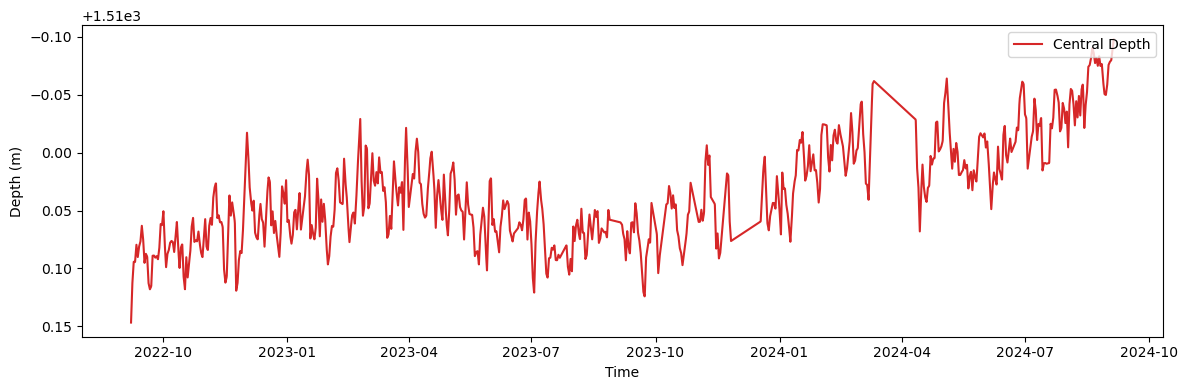

In [196]:


# plot
import matplotlib.pyplot as plt

# constants
rho = 1025.0    # kg m⁻³ (typical seawater)
g   = 9.81      # m s⁻²

# convert pressure (kPa) ➜ depth (m)
depth = p3 * 1000 / (rho * g)

# single plot
plt.figure(figsize=(12, 4))
plt.plot(time, depth, color='tab:red', label='Central Depth')
plt.gca().invert_yaxis()       # optional: 0 m at top
plt.xlabel('Time')
plt.ylabel('Depth (m)')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()



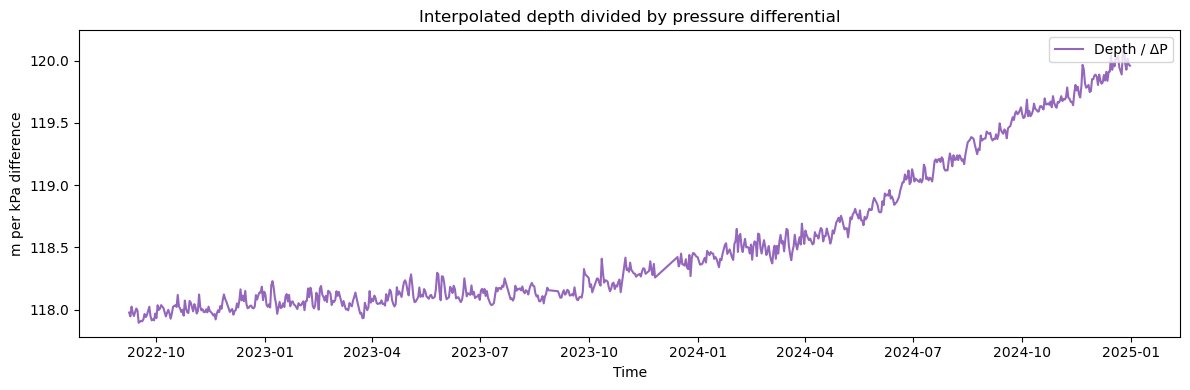

In [197]:
import pandas as pd
import matplotlib.pyplot as plt

# ────────────────── constants ──────────────────
rho = 1025.0      # kg m-3  (seawater density)
g   = 9.81        # m s-2  (gravity)

# ───────── 1)  depth series from p3  ───────────
depth_idx = pd.to_datetime(time)                 # original p3 timestamps
depth_idx = depth_idx.tz_localize("UTC")         # make them tz-aware

p3_series = pd.Series(p3, index=depth_idx)       # kPa
depth_m   = p3_series * 1000.0 / (rho * g)       # convert → metres

# ───────── 2)  differential-pressure series ───
pd2_utc = (
    df_pressure1
      .assign(time=lambda d: pd.to_datetime(d["time"], utc=True))
      .set_index("time")["pressure_diff"]
)

# ───────── 3)  interpolate depth onto pd2 times ─
depth_interp = (
    depth_m
      .reindex(depth_m.index.union(pd2_utc.index))
      .interpolate(method="time")
      .loc[pd2_utc.index]
)

# ───────── 4)  ratio & plot  ───────────────────
ratio = depth_interp / pd2_utc

plt.figure(figsize=(12, 4))
plt.plot(ratio.index, ratio, color="tab:purple", label="Depth / ΔP")
plt.xlabel("Time")
plt.ylabel("m per kPa difference")
plt.title("Interpolated depth divided by pressure differential")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


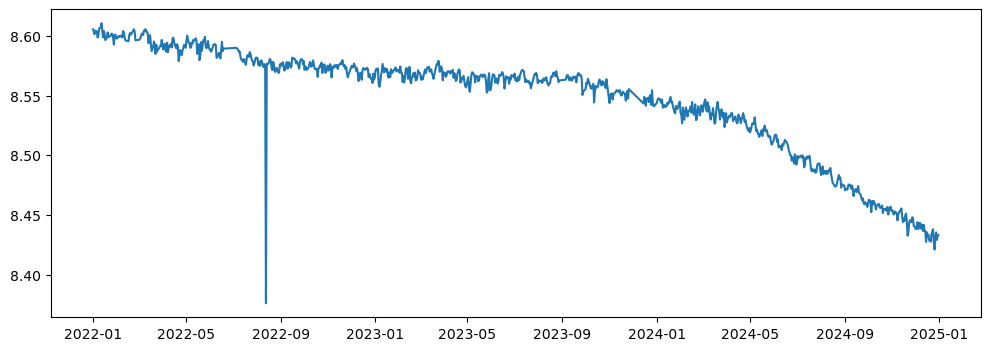

In [146]:
plt.figure(figsize=(12, 4))
plt.plot(ratio.index,pd2_utc*0.67)